In [1]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

"Reign Over Me (titled after the who song) is a movie that is sure to bring a tear to almost everyone's eye. It was a moving story of a guy (sandler) that lost his family in the 9-11 world trade center attacks. Years later, he runs into an old college roommate (cheadle) that he doesn't even recognize due to the post-dramatic stress ensued by the loss of his family. The two rekindle their old friendship and Cheadle's character, Johnson, realizes that he must get Sandler's character, Fineman, some help before it's too late.<br /><br />This was the first movie that has made me cry in a long time. It's completely worth watching and after seeing it, I'm positive the viewer will appreciate his or her family much more."

In [5]:
print(preprocess(df.iloc[random_num]['review']))

reign titled song movie sure bring tear almost everyone eye moving story guy sandler lost family world trade center attack year later run old college roommate cheadle even recognize due post dramatic stress ensued loss family two rekindle old friendship cheadle character johnson realizes must get sandler character fineman help late first movie made cry long time completely worth watching seeing positive viewer appreciate family much


In [6]:
df['review'] = df['review'].apply(preprocess)

In [7]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [8]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [10]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [11]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [12]:
max_len = 4

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [13]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(4, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(4, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 4, 4)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 4, 4)           │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 4)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,169 (313.16 KB)

 Trainable params: 80,169 (313.16 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [15]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5014 - loss: 0.6931 - val_accuracy: 0.5361 - val_loss: 0.6930 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5219 - loss: 0.6919 - val_accuracy: 0.5296 - val_loss: 0.6886 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5685 - loss: 0.6824 - val_accuracy: 0.6624 - val_loss: 0.6672 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6278 - loss: 0.6621 - val_accuracy: 0.6760 - val_loss: 0.6423 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6593 - loss: 0.6441 - val_accuracy: 0.6809 - val_loss: 0.6273 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6786 - loss: 0.6272 - val_accuracy: 0.6827 - val_loss: 0.6177 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc

In [16]:
lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [17]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

In [18]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [19]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6889 - loss: 0.6009
Test Accuracy: 0.6888999938964844


# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


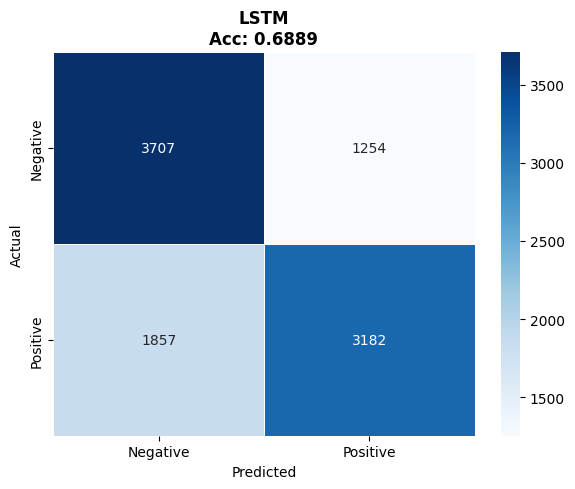

In [20]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [21]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.67      0.75      0.70      4961
    Positive       0.72      0.63      0.67      5039

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



In [42]:

def preprocess(text):
    text = re.sub(r'\\', '', text)
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[\d\W]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = text.strip()

    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = [t for t in tokens if len(t) >= 3]

    return " ".join(tokens)


FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)

# ============================================================
# ENDERECO DE 21 BITS
# ============================================================
def build_addr(layer, is_bias, is_lstm, gate, neuron, recurrent, idx):
    addr = 0
    addr |= (layer     & 0xF)   << 17  # bits 20-17: camada (max 16)
    addr |= (is_bias   & 0x1)   << 16  # bit 16:    bias
    addr |= (is_lstm   & 0x1)   << 15  # bit 15:    lstm
    addr |= (gate      & 0x3)   << 13  # bits 14-13: porta LSTM
    addr |= (neuron    & 0x3F)  << 7   # bits 12-7:  neuronio (max 64)
    addr |= (recurrent & 0x1)   << 6   # bit 6:     recorrente
    addr |= (idx       & 0x3F)        # bits 5-0:   indice (max 64)
    return addr

# ============================================================
# EXPORTA PESOS DA LSTM (ignorando Embedding)
# ============================================================
def export_lstm_weights(model, output_file="weights_lstm.mem"):
    print("\n" + "="*50)
    print("MODO LSTM: Exportando pesos a partir da primeira LSTM")
    print("Ignorando: Embedding e SpatialDropout1D")
    print("="*50)
    
    mem = {}
    layer_idx = 0  # camada 0 = primeira LSTM
    
    # Percorre as camadas do modelo
    for layer in model.layers:
        # Pula camadas que nao tem pesos
        if len(layer.get_weights()) == 0:
            continue
            
        # Verifica se é LSTM (incluindo Bidirectional)
        if isinstance(layer, Bidirectional):
            # Bidirectional tem 2 LSTMs (forward e backward)
            print(f"\nCamada {layer_idx}: Bidirectional LSTM")
            
            forward_lstm = layer.forward_layer
            backward_lstm = layer.backward_layer
            
            # Exporta forward LSTM
            export_lstm_core(forward_lstm, mem, layer_idx, direction=0)
            # Exporta backward LSTM (proxima camada)
            export_lstm_core(backward_lstm, mem, layer_idx + 1, direction=1)
            
            layer_idx += 2  # Duas camadas (forward e backward)
            
        elif isinstance(layer, LSTM):
            print(f"\nCamada {layer_idx}: LSTM")
            export_lstm_core(layer, mem, layer_idx, direction=0)
            layer_idx += 1
            
        elif isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
    
    # Salva arquivo
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# EXPORTA PESOS DA LSTM (core)
# ============================================================
def export_lstm_core(lstm_layer, mem, layer_idx, direction=0):
    """
    Exporta pesos de uma camada LSTM
    direction: 0 = forward, 1 = backward (apenas para identificacao)
    """
    weights = lstm_layer.get_weights()
    
    # LSTM tem 3 matrizes de pesos e 3 biases (ou 2 se usar bias=False)
    # weights[0]: kernel (input weights) - formato: (input_dim, 4 * units)
    # weights[1]: recurrent_kernel (recurrent weights) - formato: (units, 4 * units)
    # weights[2]: bias (se existir) - formato: (4 * units,)
    
    units = lstm_layer.units
    input_dim = weights[0].shape[0]
    
    # Separa os pesos para cada porta (forget, input, candidate, output)
    # Ordem: i, f, c, o (input, forget, candidate, output)
    kernel = weights[0].T  # Transpoe para (4*units, input_dim)
    recurrent_kernel = weights[1].T  # Transpoe para (4*units, units)
    
    # Bias
    has_bias = len(weights) > 2
    if has_bias:
        bias = weights[2]
    else:
        bias = np.zeros(4 * units)
    
    # Para cada porta
    gates = ['input', 'forget', 'candidate', 'output']
    #gates = ['candidate', 'forget', 'input', 'output']
    
    for gate_idx, gate_name in enumerate(gates):
        # Pesos de entrada (Wx)
        kernel_gate = kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for inp in range(input_dim):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel_gate[n, inp])
                
                # Mostra alguns exemplos (opcional)
                if n < 2 and inp < 2:
                    print(f"  addr=0x{addr:05X} Wx_{gate_name}[{n}][{inp}] = {kernel_gate[n, inp]:.6f}")
        
        # Pesos recorrentes (Wh)
        rec_gate = recurrent_kernel[gate_idx * units:(gate_idx + 1) * units, :]
        for n in range(units):
            for prev_n in range(units):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=1,
                    gate=gate_idx,
                    neuron=n,
                    recurrent=1,
                    idx=prev_n
                )
                mem[addr] = float_to_q16(rec_gate[n, prev_n])
                
                if n < 2 and prev_n < 2:
                    print(f"  addr=0x{addr:05X} Wh_{gate_name}[{n}][{prev_n}] = {rec_gate[n, prev_n]:.6f}")
        
        # Bias
        bias_gate = bias[gate_idx * units:(gate_idx + 1) * units]
        for n in range(units):
            addr = build_addr(
                layer=layer_idx,
                is_bias=1,
                is_lstm=1,
                gate=gate_idx,
                neuron=n,
                recurrent=0,
                idx=0
            )
            mem[addr] = float_to_q16(bias_gate[n])
            
            if n < 2:
                print(f"  addr=0x{addr:05X} bias_{gate_name}[{n}] = {bias_gate[n]:.6f}")

# ============================================================
# EXPORTA PESOS DA DENSE (MLP comum)
# ============================================================
def export_dense_core(dense_layer, mem, layer_idx):
    """Exporta pesos de uma camada Dense"""
    weights = dense_layer.get_weights()
    
    if len(weights) >= 1:
        kernel = weights[0].T  # Transpoe para (output_dim, input_dim)
        n_neurons, n_inputs = kernel.shape
        
        # Pesos
        for n in range(n_neurons):
            for inp in range(n_inputs):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=0,
                    is_lstm=0,  # Nao é LSTM
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=inp
                )
                mem[addr] = float_to_q16(kernel[n, inp])
                
                if n < 3 and inp < 3:
                    print(f"  addr=0x{addr:05X} weight[{n}][{inp}] = {kernel[n, inp]:.6f}")
        
        # Biases
        if len(weights) >= 2:
            bias = weights[1]
            for n in range(n_neurons):
                addr = build_addr(
                    layer=layer_idx,
                    is_bias=1,
                    is_lstm=0,
                    gate=0,
                    neuron=n,
                    recurrent=0,
                    idx=0
                )
                mem[addr] = float_to_q16(bias[n])
                
                if n < 3:
                    print(f"  addr=0x{addr:05X} bias[{n}] = {bias[n]:.6f}")

# ============================================================
# EXPORTA COMO MLP (ignorando LSTM)
# ============================================================
def export_mlp_weights(model, output_file="weights_mlp.mem"):
    print("\n" + "="*50)
    print("MODO MLP: Exportando pesos como rede neural comum")
    print("Todas as camadas Dense sao consideradas")
    print("="*50)
    
    mem = {}
    layer_idx = 0
    
    for layer in model.layers:
        if len(layer.get_weights()) == 0:
            continue
            
        if isinstance(layer, Dense):
            print(f"\nCamada {layer_idx}: Dense")
            export_dense_core(layer, mem, layer_idx)
            layer_idx += 1
        elif isinstance(layer, Bidirectional) or isinstance(layer, LSTM):
            print(f"\nAviso: Pulando camada LSTM no modo MLP")
            continue
    
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"\nArquivo salvo: {output_file}")
    print(f"Total de pesos: {len(mem)}")
    return mem

# ============================================================
# FUNCAO PRINCIPAL
# ============================================================
def export_weights(model, mode='lstm', output_file=None):
    """
    Exporta pesos do modelo
    
    Args:
        model: Modelo Keras
        mode: 'lstm' (ignora Embedding) ou 'mlp' (apenas camadas Dense)
        output_file: Nome do arquivo de saida
    """
    if mode == 'lstm':
        if output_file is None:
            output_file = "weights_lstm.mem"
        return export_lstm_weights(model, output_file)
    elif mode == 'mlp':
        if output_file is None:
            output_file = "weights_mlp.mem"
        return export_mlp_weights(model, output_file)
    else:
        raise ValueError("Modo deve ser 'lstm' ou 'mlp'")

def export_matrix_to_mem(matrix, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
    
    print(f"Arquivo salvo: {output_file}")
    return mem


def float_to_q16_16(value):
    """Converte float para Q16.16 (formato signed 32 bits)"""
    scaled = value * 65536
    rounded = int(round(scaled))

    if rounded > 2**31 - 1:
        rounded = 2**31 - 1
    elif rounded < -2**31:
        rounded = -2**31

    return rounded


def gerar_x_array_2d(valores):
    """
    Gera código:
    x[i][j] = ±32'sdN;

    Aceita:
        shape (N,M)
        ou (1,N,M)
    """

    # remove dimensão batch se existir
    if len(valores) == 1 and isinstance(valores[0][0], list):
        valores = valores[0]

    linhas = []

    for i, linha in enumerate(valores):

        linha_atual = ""

        for j, valor in enumerate(linha):

            qval = float_to_q16_16(valor)

            if qval >= 0:
                atrib = f"x[{i}][{j}] =  32'sd{qval};"
            else:
                atrib = f"x[{i}][{j}] = -32'sd{abs(qval)};"

            linha_atual += f"{atrib}   "

        linhas.append(linha_atual.rstrip())

    return "\n".join(linhas)

In [46]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[4].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
Outputs salvos em layer_outputs_simplified_model.txt


In [38]:
lstm_model.weights[7]

<Variable path=sequential/dense_1/bias, shape=(1,), dtype=float32, value=[-0.61868954]>

# Exportação de Pesos

In [43]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm_small.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = 0.171734
  addr=0x08001 Wx_input[0][1] = 0.509191
  addr=0x08080 Wx_input[1][0] = -0.303437
  addr=0x08081 Wx_input[1][1] = -0.550261
  addr=0x08040 Wh_input[0][0] = 0.352584
  addr=0x08041 Wh_input[0][1] = -0.100236
  addr=0x080C0 Wh_input[1][0] = 0.454411
  addr=0x080C1 Wh_input[1][1] = 0.157506
  addr=0x18000 bias_input[0] = 0.485530
  addr=0x18080 bias_input[1] = 0.409183
  addr=0x0A000 Wx_forget[0][0] = -0.381103
  addr=0x0A001 Wx_forget[0][1] = -0.454008
  addr=0x0A080 Wx_forget[1][0] = -0.521489
  addr=0x0A081 Wx_forget[1][1] = -0.411471
  addr=0x0A040 Wh_forget[0][0] = 0.047902
  addr=0x0A041 Wh_forget[0][1] = -0.447726
  addr=0x0A0C0 Wh_forget[1][0] = -0.555918
  addr=0x0A0C1 Wh_forget[1][1] = 0.052200
  addr=0x1A000 bias_forget[0] = 1.167603
  addr=0x1A080 bias_forget[1] = 1.172206
  addr=0x0C000 Wx_candidate[0][0] = -0.936091
  addr=0

# Teste Global

In [23]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [24]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [25]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 100

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"Small Global Processing/dados_{i}.mem")

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
Arquivo salvo: Small Global Processing/dados_0.mem
0 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Arquivo salvo: Small Global Processing/dados_1.mem
1 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Arquivo salvo: Small Global Processing/dados_2.mem
2 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Arquivo salvo: Small Global Processing/dados_3.mem
3 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Arquivo salvo: Small Global Processing/dados_4.mem
4 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Arquivo salvo: Small Global Processing/dados_5.mem
5 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Arquivo salvo: Small Global Processing/dados_6.mem
6 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: Small Global Processing/dados_7.mem
7 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: Small Global Processing/dados_8.mem
8 de 100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Arquivo salvo: Small Global Processing/dados_9.mem
9 de 100
1/1 ━━━━━━━━━━━━━━━